# Notebook 04: Rich/Cheap — Valor Relativo Intragrupo

Detección de bonos que cotizan por encima o por debajo de la curva Nelson-Siegel del día.

**Objetivo:** Identificar qué bonos están *baratos* (TIR > TIR_NS → precio bajo) o *caros* (TIR < TIR_NS → precio alto) respecto al ajuste de la curva.

**Definición:**
$$\text{Residual}_i(t) = \text{TIR}_i(t) - \hat{y}_{\text{NS}}(\tau_i, t)$$
- **Positivo** → bono *cheap* (TIR real > curva teórica)
- **Negativo** → bono *rich* (TIR real < curva teórica)

**Z-score rolling:**
$$z_i(t) = \frac{\text{Residual}_i(t) - \mu_i^{(W)}}{\sigma_i^{(W)}}$$
donde la media y desvío se calculan sobre una ventana deslizante de $W$ días.

**Contenido:**
1. Setup + carga de datos
2. Ajuste NS diario (reutilizado de NB03)
3. Residuales — heatmap fecha × ticker
4. Z-scores rolling — evolución temporal
5. Estado actual: snapshot Rich/Cheap de hoy
6. Episodios de dislocación pasada

In [61]:
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from dotenv import load_dotenv
load_dotenv(os.path.join(project_root, '.env'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit
from sqlalchemy import text
from src.db.session import SessionLocal

print('Setup OK')

Setup OK


In [62]:
# ─────────────────────────────────────────
#  PARÁMETROS — modificar acá
# ─────────────────────────────────────────
FECHA_INICIO_LECER = '2026-02-02'   # primer día con ≥5 LECER vigentes
FECHA_INICIO_CER   = '2025-12-08'   # régimen actual (definido en NB02)

MIN_BONOS_LECER = 5
MIN_BONOS_CER   = 4

VENTANA_LECER = 10   # días rolling para z-score LECER (21 días totales)
VENTANA_CER   = 20   # días rolling para z-score CER (56 días totales)

UMBRAL_Z = 1.5       # |z| > UMBRAL_Z → señal rich/cheap

In [63]:
# ── Carga de datos ────────────────────────────────────────────
with SessionLocal() as db:
    df_lecer = pd.read_sql(
        text("""
            SELECT p.ticker, p.fecha, m.tir, m.duration_modificada
            FROM precios_raw p
            JOIN metricas_diarias m ON m.precio_id = p.id
            JOIN bonos b ON b.ticker = p.ticker
            WHERE b.grupo = 'lecer'
              AND p.fecha >= :inicio
            ORDER BY p.fecha, m.duration_modificada
        """),
        db.bind,
        params={'inicio': FECHA_INICIO_LECER},
        parse_dates=['fecha']
    )
    df_cer = pd.read_sql(
        text("""
            SELECT p.ticker, p.fecha, m.tir, m.duration_modificada
            FROM precios_raw p
            JOIN metricas_diarias m ON m.precio_id = p.id
            JOIN bonos b ON b.ticker = p.ticker
            WHERE b.grupo = 'cer'
              AND p.fecha >= :inicio
            ORDER BY p.fecha, m.duration_modificada
        """),
        db.bind,
        params={'inicio': FECHA_INICIO_CER},
        parse_dates=['fecha']
    )

for _df in (df_lecer, df_cer):
    _df['tir']                = _df['tir'].astype(float)
    _df['duration_modificada'] = _df['duration_modificada'].astype(float)

df_lecer = df_lecer.dropna(subset=['tir', 'duration_modificada'])
df_cer   = df_cer.dropna(subset=['tir', 'duration_modificada'])

print(f'LECER: {len(df_lecer):,} obs | {df_lecer["fecha"].nunique()} días | '
      f'{df_lecer["fecha"].min().date()} → {df_lecer["fecha"].max().date()}')
print(f'CER:   {len(df_cer):,} obs | {df_cer["fecha"].nunique()} días | '
      f'{df_cer["fecha"].min().date()} → {df_cer["fecha"].max().date()}')
print(f'\nLECER tickers ({df_lecer["ticker"].nunique()}): {sorted(df_lecer["ticker"].unique())}')
print(f'CER   tickers ({df_cer["ticker"].nunique()}): {sorted(df_cer["ticker"].unique())}')

LECER: 131 obs | 25 días | 2026-02-02 → 2026-03-08
CER:   942 obs | 60 días | 2025-12-09 → 2026-03-08

LECER tickers (6): ['TZXA7', 'TZXY7', 'X15Y6', 'X29Y6', 'X30N6', 'X31L6']
CER   tickers (16): ['CUAP', 'DICP', 'DIP0', 'PAP0', 'PARP', 'TX26', 'TX28', 'TX31', 'TZX26', 'TZX27', 'TZX28', 'TZXD6', 'TZXD7', 'TZXM6', 'TZXM7', 'TZXO6']


In [64]:
# ── Modelo Nelson-Siegel (idéntico a NB03) ────────────────────

def nelson_siegel(tau, beta0, beta1, beta2, lam):
    with np.errstate(over='ignore', invalid='ignore'):
        x  = tau / lam
        f1 = np.where(x < 1e-10, 1.0, (1.0 - np.exp(-x)) / x)
        f2 = f1 - np.exp(-x)
    return beta0 + beta1 * f1 + beta2 * f2


def ajustar_ns_dia(df_dia, lam_fijo=None, min_puntos=3):
    df_dia = df_dia[df_dia['duration_modificada'] > 0].dropna(subset=['tir', 'duration_modificada'])
    if len(df_dia) < min_puntos:
        return None

    d       = df_dia['duration_modificada'].values
    y       = df_dia['tir'].values
    tickers = df_dia['ticker'].values

    idx = np.argsort(d)
    slope_init = float(y[idx[0]] - y[idx[-1]])

    try:
        if lam_fijo is not None:
            def ns_fixed(tau, b0, b1, b2):
                return nelson_siegel(tau, b0, b1, b2, lam_fijo)
            popt, _ = curve_fit(
                ns_fixed, d, y,
                p0=[float(np.mean(y)), slope_init, 0.0],
                bounds=([-0.5, -0.5, -0.5], [0.5, 0.5, 0.5]),
                maxfev=5000
            )
            beta0, beta1, beta2 = popt
            lam = lam_fijo
        else:
            popt, _ = curve_fit(
                nelson_siegel, d, y,
                p0=[float(np.mean(y)), slope_init, 0.0, 1.0],
                bounds=([-0.5, -0.5, -0.5, 0.05], [0.5, 0.5, 0.5, 10.0]),
                maxfev=5000
            )
            beta0, beta1, beta2, lam = popt
    except Exception:
        return None

    y_pred   = nelson_siegel(d, beta0, beta1, beta2, lam)
    resid_pp = (y - y_pred) * 100
    rmse_pp  = float(np.sqrt(np.mean(resid_pp ** 2)))

    return {
        'beta0':      beta0,
        'beta1':      beta1,
        'beta2':      beta2,
        'lam':        lam,
        'rmse_pp':    rmse_pp,
        'residuales': dict(zip(tickers, resid_pp)),
    }


print('Funciones NS cargadas')

Funciones NS cargadas


In [65]:
# ── Ajuste NS diario ──────────────────────────────────────────
def ajustar_grupo(df_raw, lam_fijo, min_bonos, nombre):
    resultados = {}
    for fecha, grupo in df_raw.groupby('fecha'):
        res = ajustar_ns_dia(grupo, lam_fijo=lam_fijo, min_puntos=min_bonos)
        if res is not None:
            resultados[fecha] = res

    resid = pd.DataFrame([
        {'fecha': f, 'ticker': t, 'residual_pp': r}
        for f, res in resultados.items()
        for t, r in res['residuales'].items()
    ])

    dias_total = df_raw['fecha'].nunique()
    print(f'{nombre}: {len(resultados)} / {dias_total} días ajustados ({len(resultados)/dias_total*100:.0f}%)')
    return resultados, resid


resultados_lecer, resid_lecer = ajustar_grupo(df_lecer, lam_fijo=None, min_bonos=MIN_BONOS_LECER, nombre='LECER')
resultados_cer,   resid_cer   = ajustar_grupo(df_cer,   lam_fijo=None, min_bonos=MIN_BONOS_CER,   nombre='CER')

LECER: 24 / 25 días ajustados (96%)
CER: 60 / 60 días ajustados (100%)


/var/folders/08/d9lc80m178b9xt2byjmp37sw0000gn/T/ipykernel_85210/49550773.py:36: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(


## 1. Heatmap Residuales (fecha × ticker)

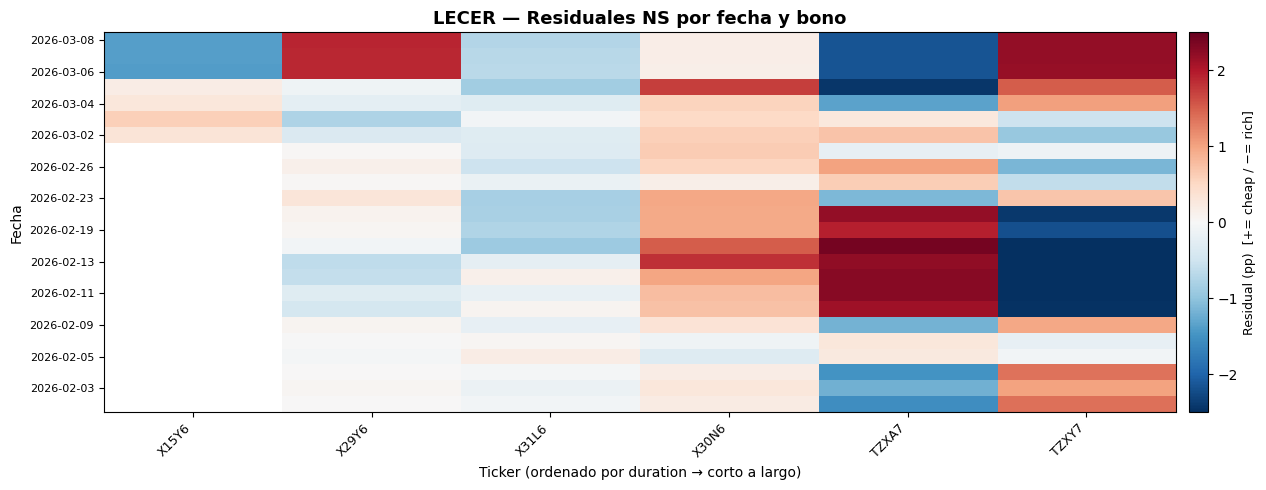

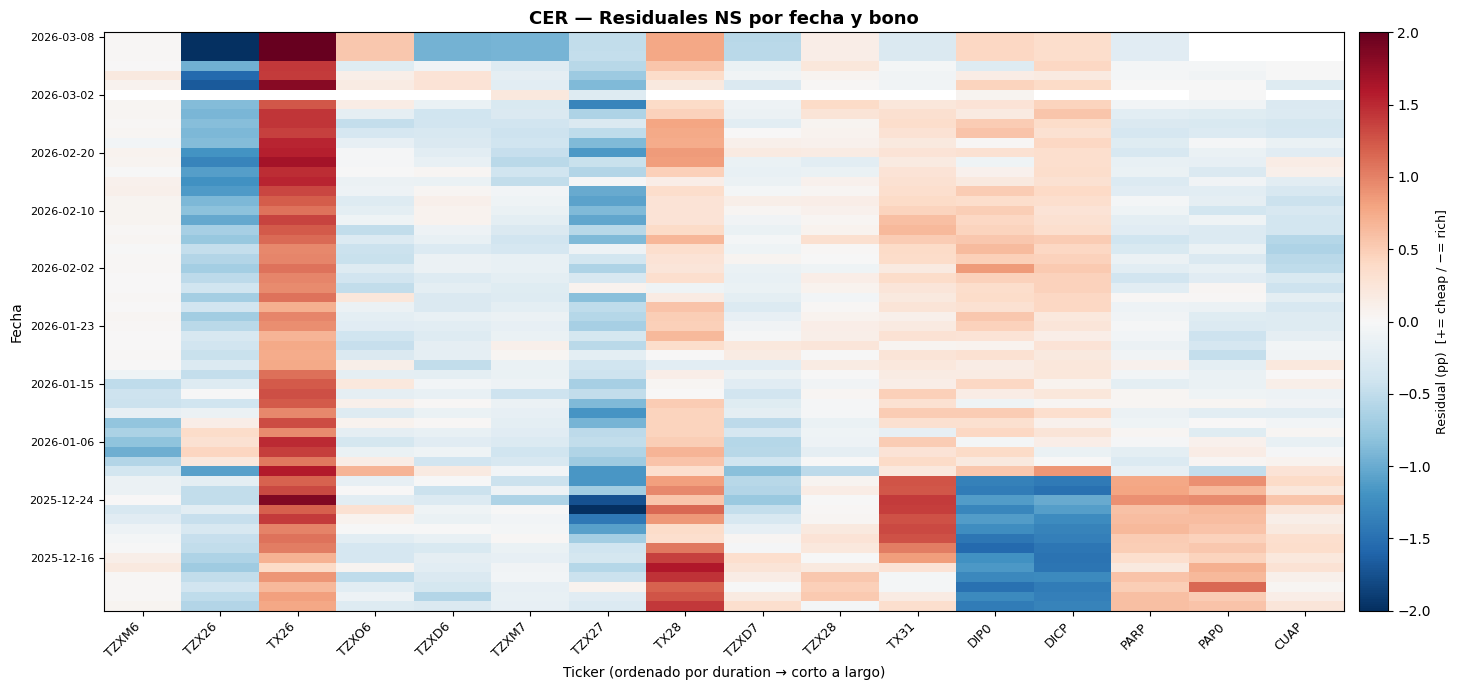

In [66]:
def heatmap_residuales(resid_df, df_raw, titulo, vmax_pp=2.0, figsize=(14, 5)):
    """
    Heatmap fecha (eje y, más reciente arriba) × ticker (eje x, ordenado por duration media).
    Color: rojo = cheap, azul = rich, blanco = en línea con la curva.
    """
    # Orden de tickers por duration media
    order = (
        df_raw.groupby('ticker')['duration_modificada']
        .median()
        .sort_values()
        .index.tolist()
    )
    tickers = [t for t in order if t in resid_df['ticker'].unique()]

    pivot = (
        resid_df.pivot(index='fecha', columns='ticker', values='residual_pp')
        .reindex(columns=tickers)
        .sort_index(ascending=False)   # más reciente arriba
    )

    fig, ax = plt.subplots(figsize=figsize)
    cmap = plt.cm.RdBu_r
    norm = mcolors.TwoSlopeNorm(vmin=-vmax_pp, vcenter=0, vmax=vmax_pp)

    im = ax.imshow(
        pivot.values,
        aspect='auto',
        cmap=cmap,
        norm=norm,
        interpolation='nearest'
    )

    ax.set_xticks(range(len(tickers)))
    ax.set_xticklabels(tickers, rotation=45, ha='right', fontsize=9)

    fechas_idx = pivot.index
    step = max(1, len(fechas_idx) // 10)
    ytick_pos = list(range(0, len(fechas_idx), step))
    ax.set_yticks(ytick_pos)
    ax.set_yticklabels([fechas_idx[i].strftime('%Y-%m-%d') for i in ytick_pos], fontsize=8)

    cbar = fig.colorbar(im, ax=ax, pad=0.01)
    cbar.set_label('Residual (pp)  [+= cheap / −= rich]', fontsize=9)

    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.set_xlabel('Ticker (ordenado por duration → corto a largo)', fontsize=10)
    ax.set_ylabel('Fecha', fontsize=10)

    plt.tight_layout()
    plt.show()


heatmap_residuales(resid_lecer, df_lecer, 'LECER — Residuales NS por fecha y bono', vmax_pp=2.5)
heatmap_residuales(resid_cer,   df_cer,   'CER — Residuales NS por fecha y bono',   vmax_pp=2.0, figsize=(16, 7))

## 2. Z-scores rolling por bono

In [67]:
def calcular_zscore_rolling(resid_df, ventana):
    """
    Para cada ticker calcula el z-score rolling del residual sobre una ventana de `ventana` días.
    Requiere al menos 3 observaciones en la ventana para emitir señal.
    """
    result_frames = []
    for ticker, grp in resid_df.groupby('ticker'):
        grp = grp.sort_values('fecha').set_index('fecha')
        roll = grp['residual_pp'].rolling(window=ventana, min_periods=3)
        mu  = roll.mean()
        std = roll.std()
        z   = (grp['residual_pp'] - mu) / std.replace(0, np.nan)
        result_frames.append(
            pd.DataFrame({'ticker': ticker, 'residual_pp': grp['residual_pp'], 'z_score': z})
        )
    return pd.concat(result_frames).reset_index()


zscores_lecer = calcular_zscore_rolling(resid_lecer, VENTANA_LECER)
zscores_cer   = calcular_zscore_rolling(resid_cer,   VENTANA_CER)

print(f'LECER — observaciones con z válido: {zscores_lecer["z_score"].notna().sum()}')
print(f'CER   — observaciones con z válido: {zscores_cer["z_score"].notna().sum()}')

LECER — observaciones con z válido: 115
CER   — observaciones con z válido: 910


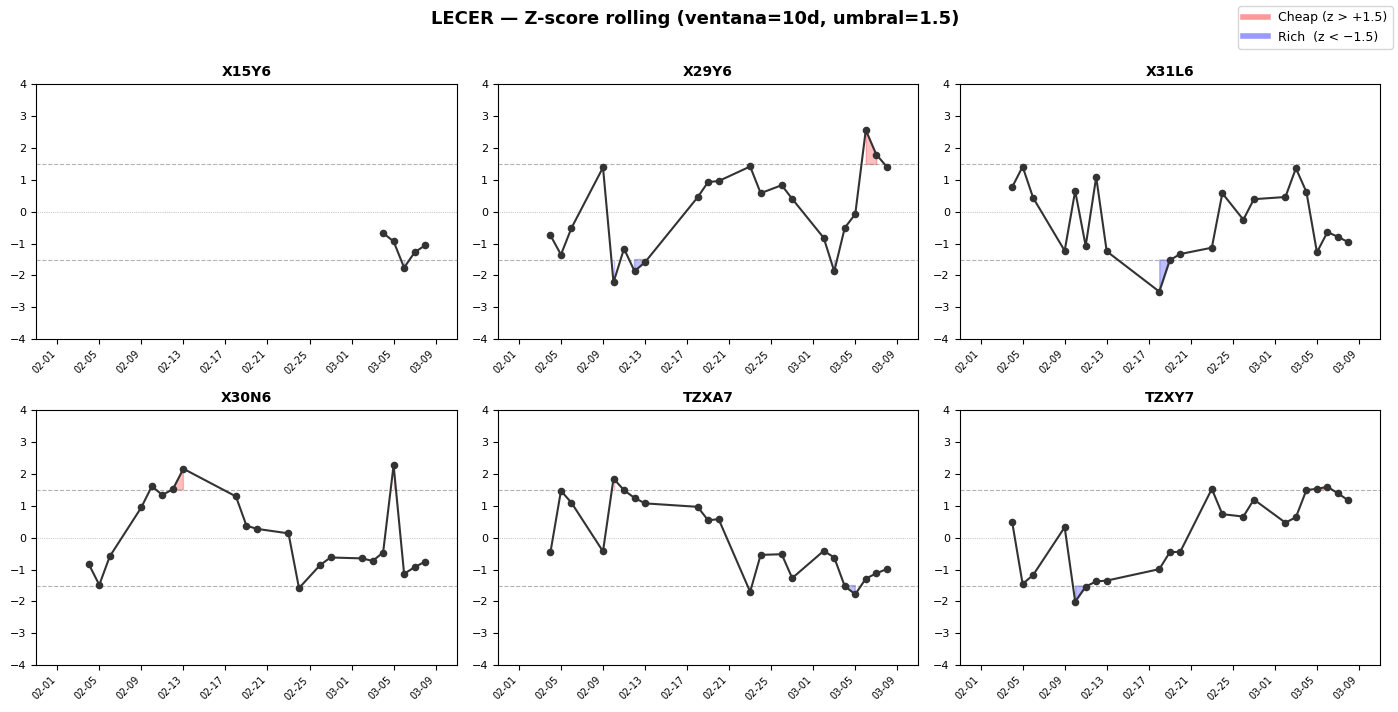

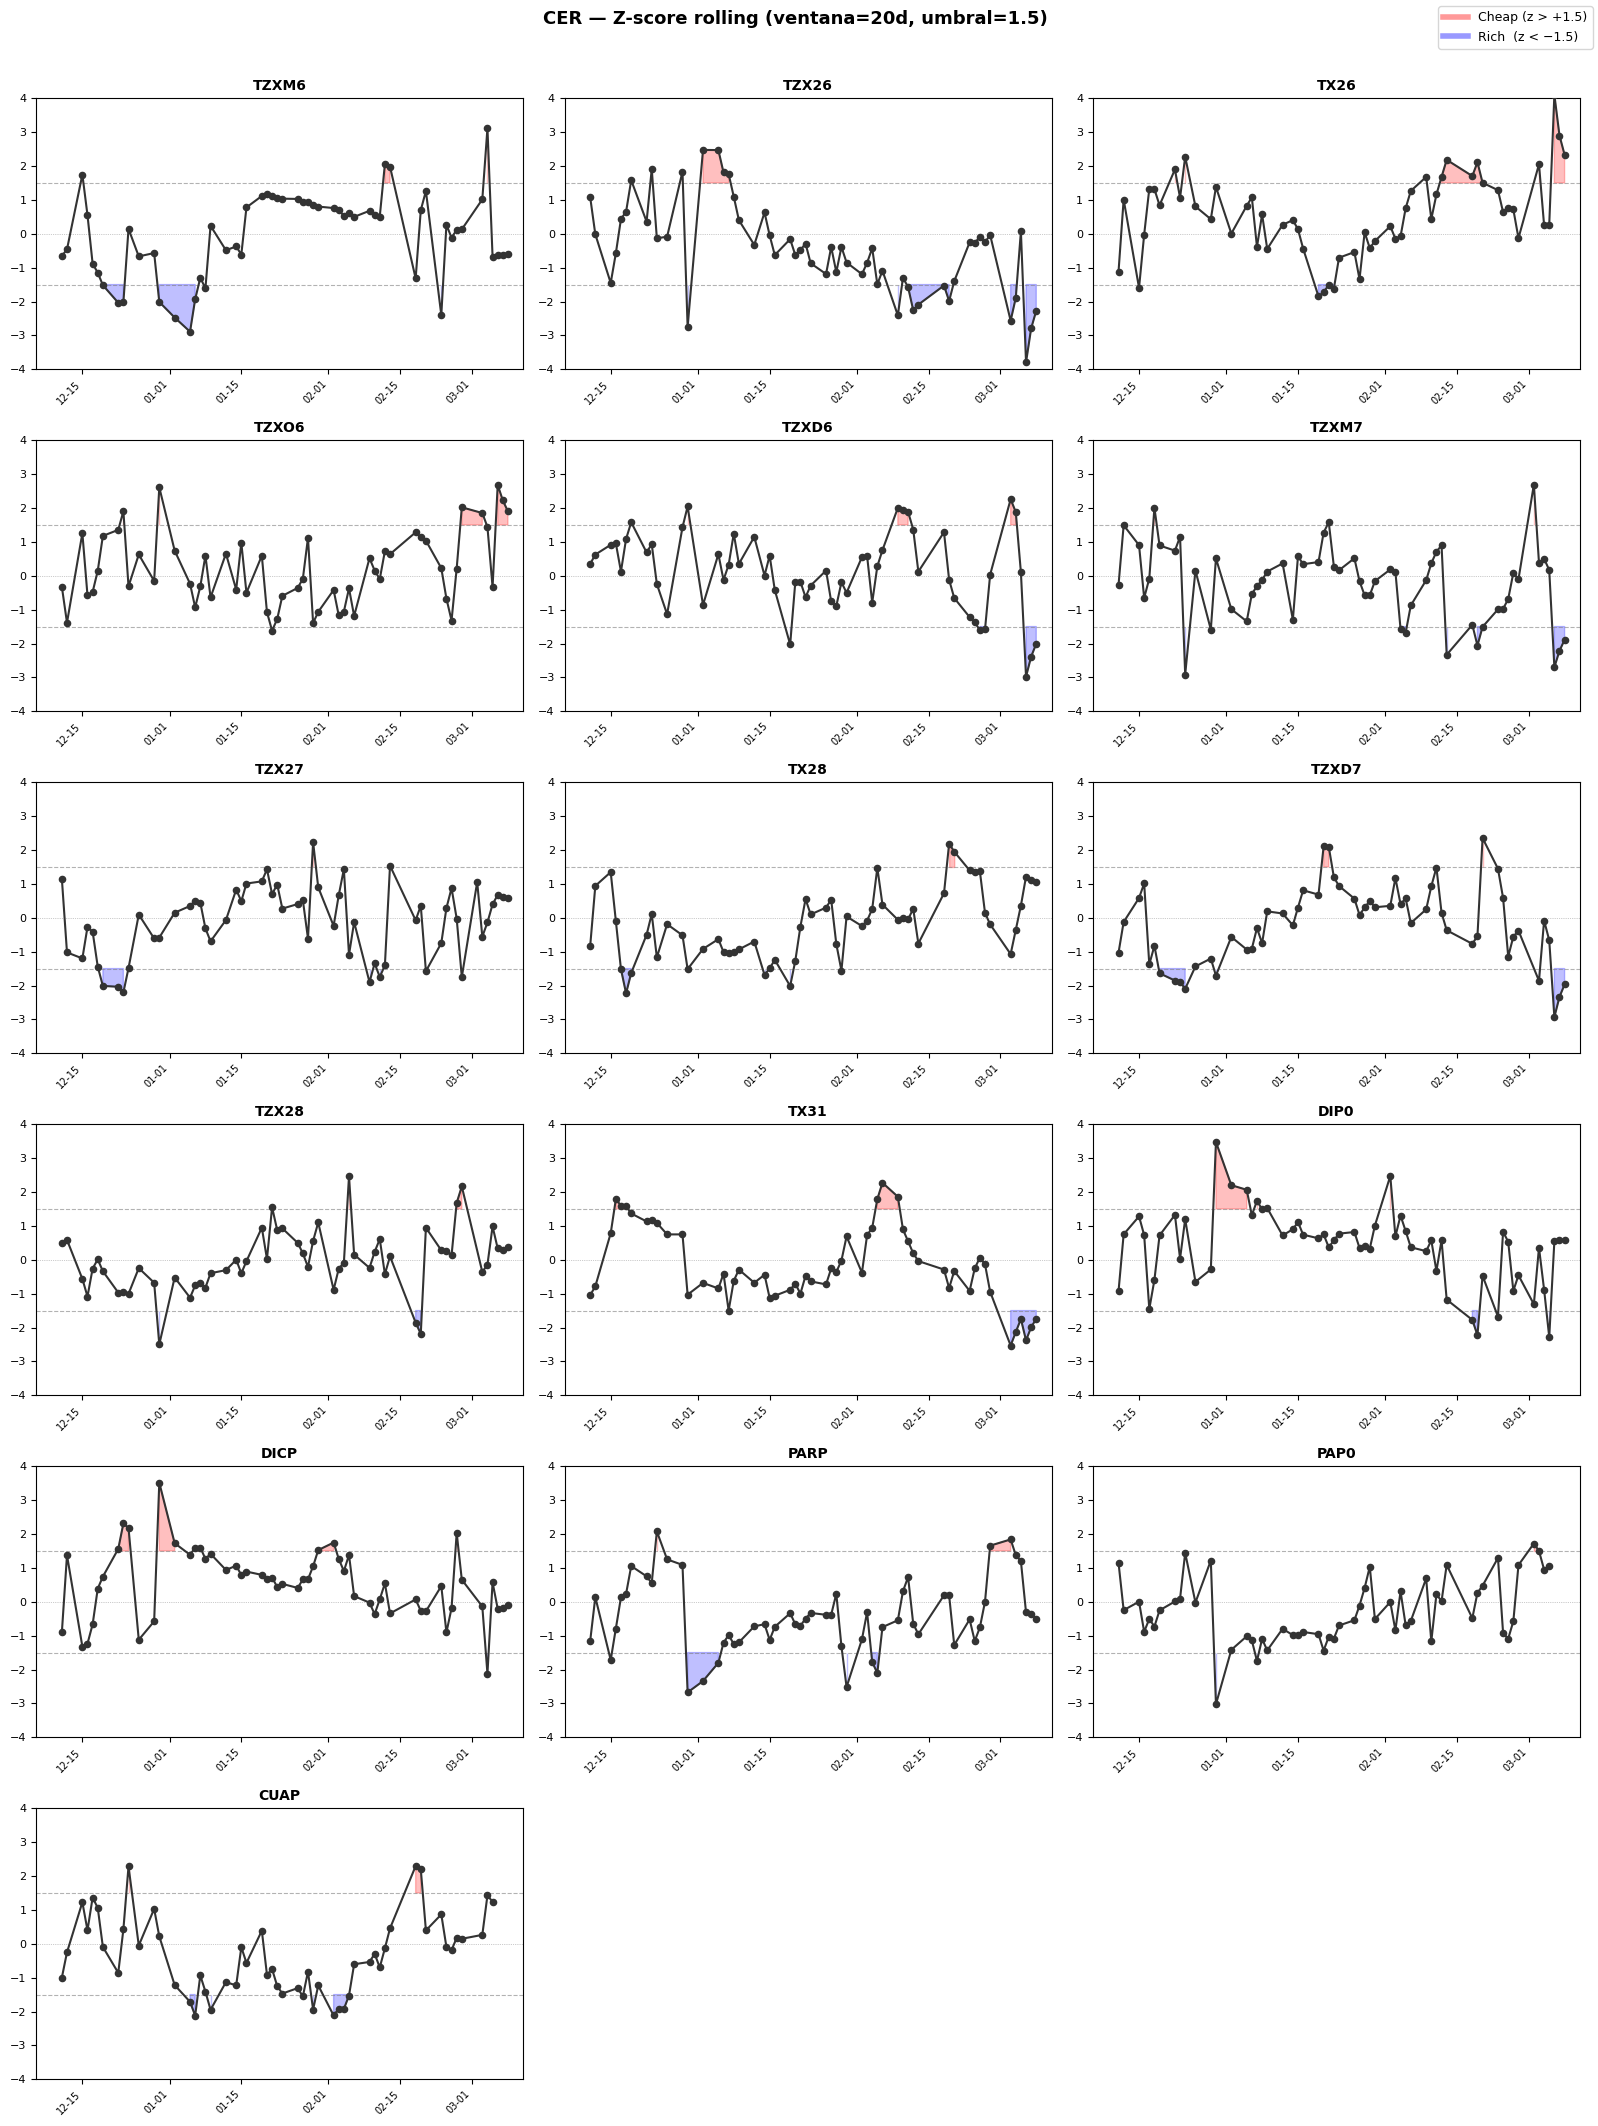

In [68]:
def plot_zscore_por_bono(zscores_df, df_raw, titulo, umbral, color_tickers=None, figsize_col=14):
    order = (
        df_raw.groupby('ticker')['duration_modificada']
        .median().sort_values().index.tolist()
    )
    tickers = [t for t in order if t in zscores_df['ticker'].unique()]
    n = len(tickers)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_col, 3.5 * nrows), sharex=False)
    axes = np.array(axes).flatten()

    # Rango global de fechas: todos los subplots usan el mismo eje x
    fecha_min = df_raw['fecha'].min()
    fecha_max = df_raw['fecha'].max()
    margen    = pd.Timedelta(days=3)

    for ax, ticker in zip(axes, tickers):
        sub = zscores_df[zscores_df['ticker'] == ticker].sort_values('fecha')
        z   = sub.set_index('fecha')['z_score']

        ax.axhline( umbral, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
        ax.axhline(-umbral, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
        ax.axhline(0, color='black', linewidth=0.5, linestyle=':', alpha=0.4)

        ax.fill_between(z.index, umbral, z.values,
                        where=(z.values > umbral), alpha=0.25, color='red', label='cheap')
        ax.fill_between(z.index, -umbral, z.values,
                        where=(z.values < -umbral), alpha=0.25, color='blue', label='rich')

        ax.plot(z.index, z.values, color='#333333', linewidth=1.5, zorder=4)
        ax.scatter(z.index, z.values, s=20, color='#333333', zorder=5)

        ax.set_title(ticker, fontsize=10, fontweight='bold')
        ax.set_xlim(fecha_min - margen, fecha_max + margen)
        ax.set_ylim(-4, 4)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
        ax.tick_params(axis='y', labelsize=8)

    for ax in axes[n:]:
        ax.set_visible(False)

    handles = [
        plt.Line2D([0], [0], color='red', linewidth=4, alpha=0.4, label=f'Cheap (z > +{umbral})'),
        plt.Line2D([0], [0], color='blue', linewidth=4, alpha=0.4, label=f'Rich  (z < −{umbral})'),
    ]
    fig.legend(handles=handles, loc='upper right', fontsize=9, frameon=True)
    plt.suptitle(titulo, fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


plot_zscore_por_bono(
    zscores_lecer, df_lecer,
    f'LECER — Z-score rolling (ventana={VENTANA_LECER}d, umbral={UMBRAL_Z})',
    UMBRAL_Z
)

plot_zscore_por_bono(
    zscores_cer, df_cer,
    f'CER — Z-score rolling (ventana={VENTANA_CER}d, umbral={UMBRAL_Z})',
    UMBRAL_Z,
    figsize_col=16
)

## 3. Estado actual: snapshot Rich/Cheap de hoy

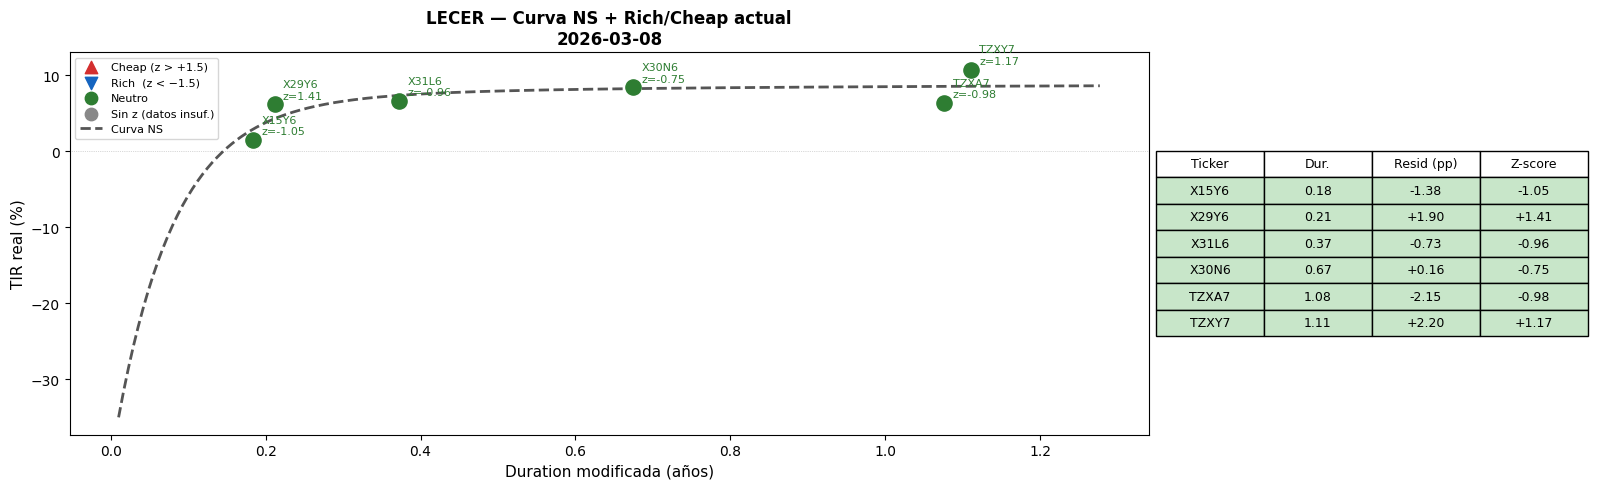

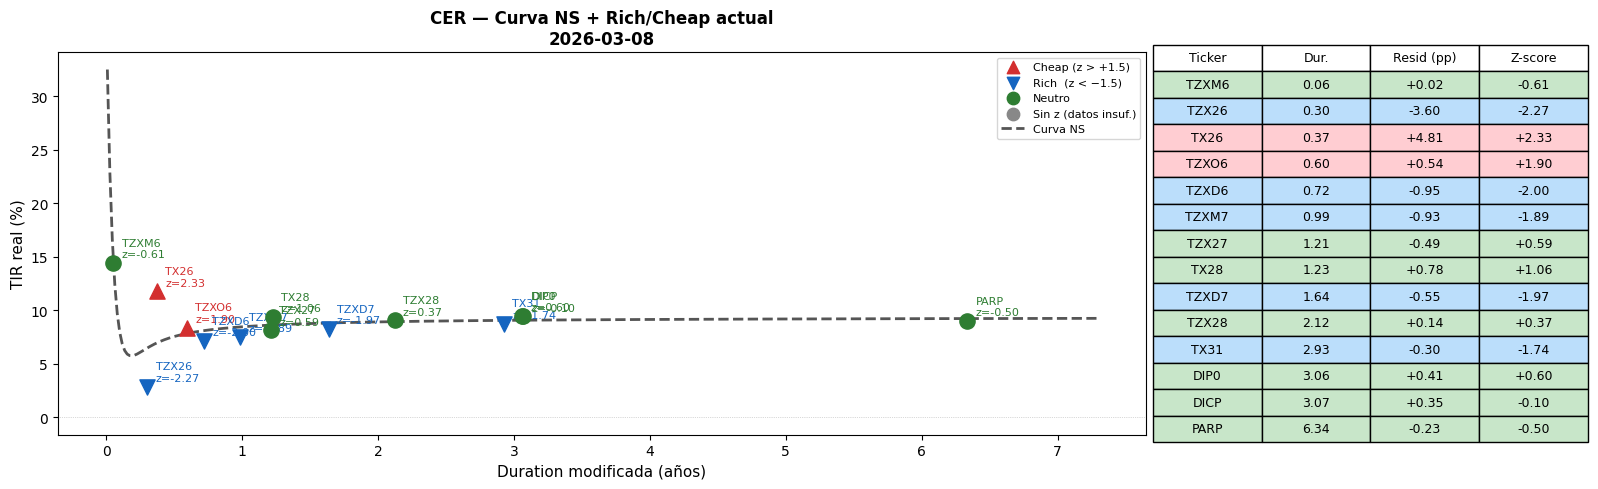

In [69]:
def snapshot_hoy(df_raw, resultados_ns, zscores_df, df_resid, titulo, umbral):
    """
    Muestra la curva NS del último día disponible con los bonos coloreados
    según su z-score actual (rojo=cheap, azul=rich, negro=neutro).
    Incluye tabla con residual y z-score por bono.
    """
    ultima_fecha = max(resultados_ns.keys())
    res          = resultados_ns[ultima_fecha]
    corte_raw    = df_raw[df_raw['fecha'] == ultima_fecha].sort_values('duration_modificada')
    corte_z      = zscores_df[zscores_df['fecha'] == ultima_fecha].set_index('ticker')
    corte_resid  = df_resid[df_resid['fecha'] == ultima_fecha].set_index('ticker')

    # Curva NS continua
    d_max = float(corte_raw['duration_modificada'].max()) * 1.15
    tau   = np.linspace(0.01, max(d_max, 0.3), 400)
    y_ns  = nelson_siegel(tau, res['beta0'], res['beta1'], res['beta2'], res['lam']) * 100

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5),
                                   gridspec_kw={'width_ratios': [3, 1]})

    # — Curva NS —
    ax1.plot(tau, y_ns, color='#555555', linewidth=2, linestyle='--', label='Curva NS', zorder=2)

    for _, row in corte_raw.iterrows():
        t     = row['ticker']
        tir   = row['tir'] * 100
        dur   = row['duration_modificada']
        z_val = corte_z.loc[t, 'z_score'] if t in corte_z.index else np.nan

        if np.isnan(z_val):
            color, marker = '#888888', 'o'
        elif z_val > umbral:
            color, marker = '#D32F2F', '^'   # cheap — rojo
        elif z_val < -umbral:
            color, marker = '#1565C0', 'v'   # rich  — azul
        else:
            color, marker = '#2E7D32', 'o'   # neutro — verde

        ax1.scatter(dur, tir, color=color, marker=marker, s=120, zorder=5)
        ax1.annotate(
            f'{t}\nz={z_val:.2f}' if not np.isnan(z_val) else t,
            (dur, tir),
            textcoords='offset points', xytext=(6, 4), fontsize=8, color=color
        )

    ax1.axhline(0, color='black', linewidth=0.5, linestyle=':', alpha=0.3)
    ax1.set_xlabel('Duration modificada (años)', fontsize=11)
    ax1.set_ylabel('TIR real (%)', fontsize=11)
    ax1.set_title(f'{titulo}\n{ultima_fecha.date()}', fontsize=12, fontweight='bold')

    handles = [
        plt.scatter([], [], color='#D32F2F', marker='^', s=80, label=f'Cheap (z > +{umbral})'),
        plt.scatter([], [], color='#1565C0', marker='v', s=80, label=f'Rich  (z < −{umbral})'),
        plt.scatter([], [], color='#2E7D32', marker='o', s=80, label='Neutro'),
        plt.scatter([], [], color='#888888', marker='o', s=80, label='Sin z (datos insuf.)'),
        plt.Line2D([0], [0], color='#555555', linewidth=2, linestyle='--', label='Curva NS'),
    ]
    ax1.legend(handles=handles, fontsize=8, loc='best')

    # — Tabla —
    rows = []
    for _, row in corte_raw.sort_values('duration_modificada').iterrows():
        t = row['ticker']
        r = corte_resid.loc[t, 'residual_pp'] if t in corte_resid.index else np.nan
        z = corte_z.loc[t, 'z_score']         if t in corte_z.index     else np.nan
        rows.append([t, f"{row['duration_modificada']:.2f}", f"{r:+.2f}" if not np.isnan(r) else '—',
                     f"{z:+.2f}" if not np.isnan(z) else '—'])

    ax2.axis('off')
    tabla = ax2.table(
        cellText=rows,
        colLabels=['Ticker', 'Dur.', 'Resid (pp)', 'Z-score'],
        cellLoc='center', loc='center'
    )
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(9)
    tabla.scale(1.2, 1.6)

    # Colorear filas según z
    for i, (_, row) in enumerate(corte_raw.sort_values('duration_modificada').iterrows()):
        t     = row['ticker']
        z_val = corte_z.loc[t, 'z_score'] if t in corte_z.index else np.nan
        if not np.isnan(z_val):
            if z_val > umbral:
                bg = '#FFCDD2'
            elif z_val < -umbral:
                bg = '#BBDEFB'
            else:
                bg = '#C8E6C9'
        else:
            bg = '#F5F5F5'
        for j in range(4):
            tabla[i + 1, j].set_facecolor(bg)

    plt.tight_layout()
    plt.show()


snapshot_hoy(df_lecer, resultados_lecer, zscores_lecer, resid_lecer,
             'LECER — Curva NS + Rich/Cheap actual', UMBRAL_Z)

snapshot_hoy(df_cer, resultados_cer, zscores_cer, resid_cer,
             'CER — Curva NS + Rich/Cheap actual', UMBRAL_Z)

## 4. Episodios de dislocación pasada

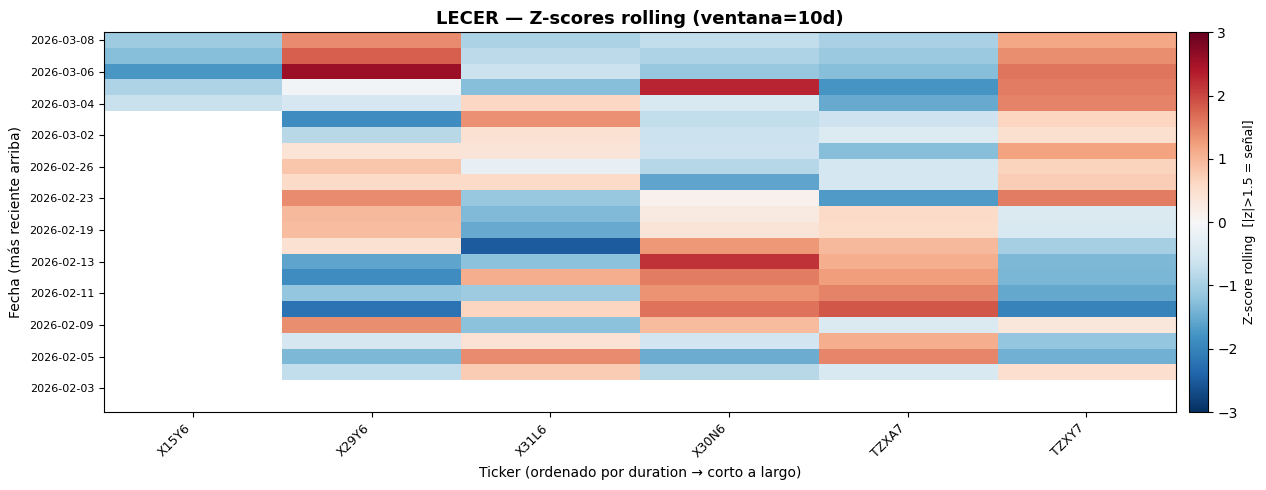


Episodios con |z| > 1.5 (23 observaciones):
     fecha ticker  residual_pp   z_score señal
2026-03-06  X29Y6     1.878581  2.563290 CHEAP
2026-03-05  X30N6     1.720651  2.276508 CHEAP
2026-02-13  X30N6     1.826440  2.166031 CHEAP
2026-02-10  TZXA7     2.113595  1.857858 CHEAP
2026-03-07  X29Y6     1.887282  1.796385 CHEAP
2026-02-10  X30N6     0.738299  1.618761 CHEAP
2026-03-06  TZXY7     2.184320  1.598609 CHEAP
2026-03-05  TZXY7     1.521388  1.535643 CHEAP
2026-02-23  TZXY7     0.688584  1.531751 CHEAP
2026-02-12  X30N6     0.989747  1.523638 CHEAP
2026-02-19  X31L6    -0.744929 -1.519650  RICH
2026-03-04  TZXA7    -1.329463 -1.521619  RICH
2026-02-11  TZXY7    -2.549753 -1.533350  RICH
2026-02-24  X30N6     0.141150 -1.581517  RICH
2026-02-13  X29Y6    -0.630263 -1.584030  RICH
2026-02-23  TZXA7    -1.118701 -1.697839  RICH
2026-03-06  X15Y6    -1.387729 -1.755826  RICH
2026-03-05  TZXA7    -2.438266 -1.776263  RICH
2026-02-12  X29Y6    -0.598465 -1.867589  RICH
2026-03-03  X29

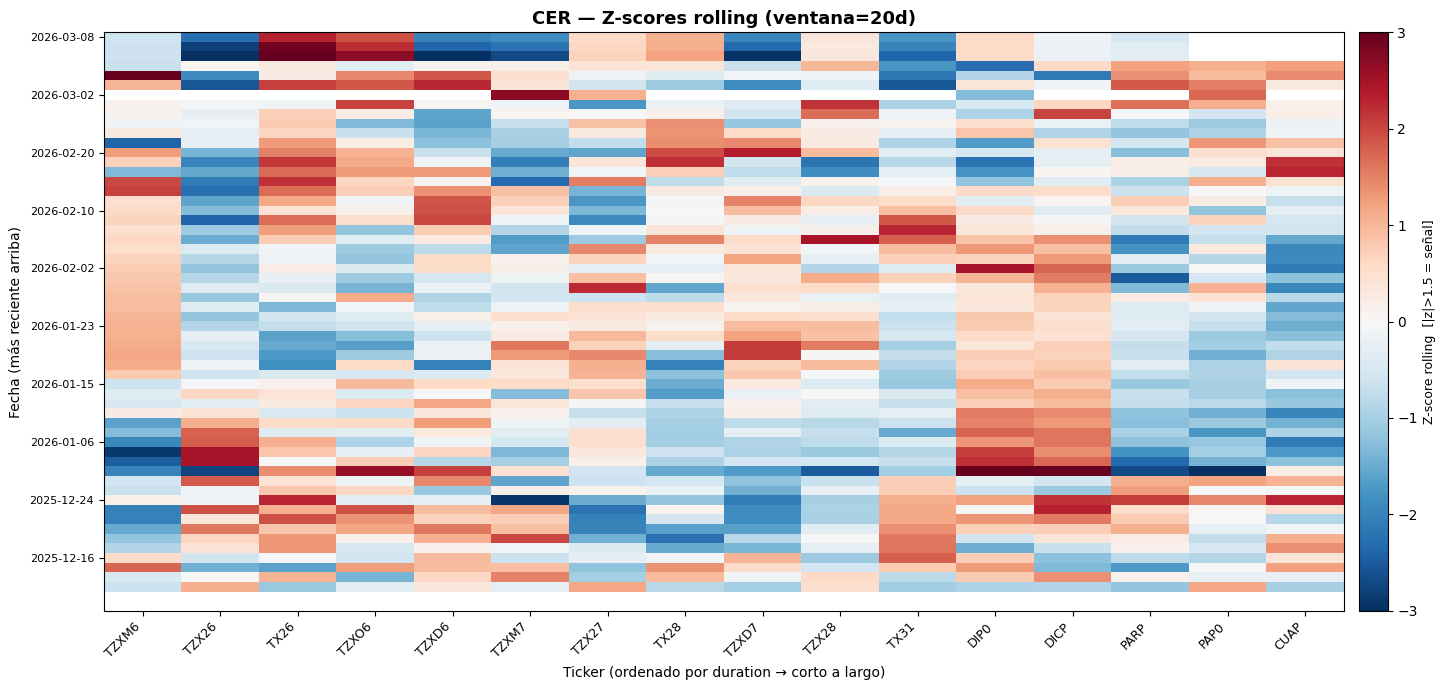


Episodios con |z| > 1.5 (180 observaciones):
     fecha ticker  residual_pp   z_score señal
2026-03-06   TX26     4.739956  4.106787 CHEAP
2025-12-30   DICP     0.885762  3.517245 CHEAP
2025-12-30   DIP0     0.534366  3.479086 CHEAP
2026-03-04  TZXM6     0.198746  3.117898 CHEAP
2026-03-07   TX26     4.776838  2.901041 CHEAP
2026-03-02  TZXM7     0.211349  2.691437 CHEAP
2026-03-06  TZXO6     0.533317  2.682503 CHEAP
2025-12-30  TZXO6     0.676425  2.614097 CHEAP
2026-01-02  TZX26     0.212468  2.476614 CHEAP
2026-02-02   DIP0     0.850979  2.474128 CHEAP
2026-01-05  TZX26     0.434888  2.471975 CHEAP
2026-02-05  TZX28     0.321725  2.461875 CHEAP
2026-02-20  TZXD7     0.181870  2.353993 CHEAP
2026-03-08   TX26     4.814461  2.330294 CHEAP
2025-12-23   DICP    -1.094872  2.314210 CHEAP
2026-02-18   CUAP     0.105769  2.296685 CHEAP
2025-12-24   CUAP     0.549853  2.287717 CHEAP
2025-12-24   TX26     1.855975  2.275426 CHEAP
2026-02-06   TX31     0.640721  2.275238 CHEAP
2026-03-03  TZ

In [70]:
def episodios_dislocacion(zscores_df, df_raw, titulo, umbral, figsize=(14, 5)):
    """
    Heatmap del z-score rolling (fecha × ticker) con bandas coloreadas.
    Rojo intenso = cheap extremo, Azul intenso = rich extremo.
    Permite ver episodios históricos de dislocación.
    """
    order = (
        df_raw.groupby('ticker')['duration_modificada']
        .median().sort_values().index.tolist()
    )
    tickers = [t for t in order if t in zscores_df['ticker'].unique()]

    pivot = (
        zscores_df.pivot(index='fecha', columns='ticker', values='z_score')
        .reindex(columns=tickers)
        .sort_index(ascending=False)
    )

    fig, ax = plt.subplots(figsize=figsize)
    norm = mcolors.TwoSlopeNorm(vmin=-3, vcenter=0, vmax=3)

    im = ax.imshow(
        pivot.values,
        aspect='auto',
        cmap='RdBu_r',
        norm=norm,
        interpolation='nearest'
    )

    ax.set_xticks(range(len(tickers)))
    ax.set_xticklabels(tickers, rotation=45, ha='right', fontsize=9)

    fechas_idx = pivot.index
    step = max(1, len(fechas_idx) // 10)
    ytick_pos = list(range(0, len(fechas_idx), step))
    ax.set_yticks(ytick_pos)
    ax.set_yticklabels([fechas_idx[i].strftime('%Y-%m-%d') for i in ytick_pos], fontsize=8)

    cbar = fig.colorbar(im, ax=ax, pad=0.01)
    cbar.set_label(f'Z-score rolling  [|z|>{umbral} = señal]', fontsize=9)

    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.set_xlabel('Ticker (ordenado por duration → corto a largo)', fontsize=10)
    ax.set_ylabel('Fecha (más reciente arriba)', fontsize=10)

    plt.tight_layout()
    plt.show()

    # Tabla de señales activas
    signals = (
        zscores_df[zscores_df['z_score'].abs() > umbral]
        .sort_values('z_score', ascending=False)
        .assign(señal=lambda d: d['z_score'].apply(lambda z: 'CHEAP' if z > 0 else 'RICH'))
        [['fecha', 'ticker', 'residual_pp', 'z_score', 'señal']]
    )
    if len(signals) > 0:
        print(f'\nEpisodios con |z| > {umbral} ({len(signals)} observaciones):')
        print(signals.to_string(index=False))
    else:
        print(f'Sin episodios con |z| > {umbral} en el período analizado')


episodios_dislocacion(
    zscores_lecer, df_lecer,
    f'LECER — Z-scores rolling (ventana={VENTANA_LECER}d)',
    UMBRAL_Z
)

episodios_dislocacion(
    zscores_cer, df_cer,
    f'CER — Z-scores rolling (ventana={VENTANA_CER}d)',
    UMBRAL_Z,
    figsize=(16, 7)
)

## Comentarios

### Rich/Cheap intragrupo
- El z-score rolling permite identificar bonos que se alejan de la curva NS del grupo de manera estadísticamente significativa.
- Un residual positivo persistente (z > 0) sugiere que el bono cotiza *cheap*: ofrece más TIR que el resto de la curva, posible oportunidad de compra si el diferencial es irracional.
- Un residual negativo (z < 0) indica *rich*: el bono cotiza a mayor precio relativo al resto.

### Limitaciones de la muestra actual
- **LECER**: solo 21 días de historia. La ventana de 10 días deja pocos puntos con z válido. Las señales deben interpretarse con cautela hasta tener al menos 30 días de datos.
- **CER**: 56 días, ventana de 20 días. Más confiable, pero aún es un período corto para caracterizar la distribución de residuales.

### Próximos pasos (NB05)
- El análisis univariado de z-score por bono se complementará con una detección multivariada (Mahalanobis) sobre el vector de parámetros NS.
- Una anomalía en Mahalanobis señala que la *forma de la curva completa* es inusual, mientras que el z-score señala un bono puntual que se desvía de la curva actual.